In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv("output/default.csv")

In [4]:
def gaussian(x, A, x_0, sigma):
    return A * np.exp(-(x - x_0)**2 / (2 * sigma**2))


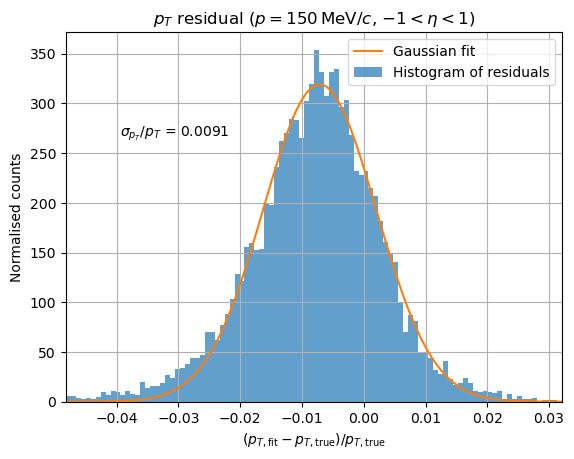

In [ ]:
eta_lo, eta_hi = -1.0, 1.0
momentum = 150

df_eta = df[(df["eta"] >= eta_lo) & (df["eta"] < eta_hi)]
subset = df_eta[df_eta["True p"] == momentum]

true_pT = np.sqrt(subset["True pX"]**2 + subset["True pY"]**2)
pT_residual = (subset["Fit pT"] - true_pT) / true_pT

sigma_guess = (np.percentile(pT_residual, 84) - np.percentile(pT_residual, 16)) / 2

mean = pT_residual.mean() 
counts, edges = np.histogram(pT_residual, bins=50, range=(mean - 2 * sigma_guess, mean + 2 * sigma_guess))
mids = (edges[:-1] + edges[1:]) / 2

popt, _ = curve_fit(gaussian, mids, counts, p0=[max(counts), mids[np.argmax(counts)], sigma_guess])

plt.hist(pT_residual, bins=100, alpha=0.7, range=(mean - 4 * sigma_guess, mean + 4 * sigma_guess))

x = np.linspace(mean - 4 * sigma_guess, mean + 4 * sigma_guess, 100)

plt.plot(x, gaussian(x, *popt))

sigma = popt[2]

plt.xlim(mean - 4 * sigma_guess, mean + 4 * sigma_guess)

plt.xlabel(r"$(p_{T,\mathrm{fit}} - p_{T,\mathrm{true}})/p_{T,\mathrm{true}}$")
plt.ylabel("Counts")
plt.title(r"$p_T$ residual ($p=150\,\mathrm{MeV}/c$, $-1 < \eta < 1$)")

plt.legend([r"Gaussian fit", r"Histogram of residuals"])

plt.text(0.11, 0.75,
         r"$\sigma_{p_T} / p_T$ = " + f"{sigma:.4f}",
         transform=plt.gca().transAxes,
         verticalalignment='top')

plt.grid()
plt.show()